In [1]:
# Cell 1 — Title & imports
"""
Notebook 04: Reproduce all paper figures
========================================
This notebook reproduces every figure in the paper from scratch
using only public data and the kai package.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from kai.data.loaders import load_gw170817_photometry, load_upper_limits
from kai.models.kilonova import KilonovaComponent, MultiComponentKilonova
from kai.inference.likelihood import (
    KilonovaLikelihood, build_model_from_params, COMPONENT_NAMES
)
from kai.inference.priors import gw170817_priors
from kai.inference.sampler import run_inference
import bilby

# Matplotlib style
plt.rcParams.update({
    "font.family":    "serif",
    "font.size":      11,
    "axes.labelsize": 12,
    "figure.dpi":     150,
})

OUTDIR = Path("../results/gw170817")
OUTDIR.mkdir(parents=True, exist_ok=True)

/home/jean/miniconda3/lib/python3.13/site-packages/bilby/core/likelihood.py:83: FutureWarning: <class 'kai.inference.likelihood.KilonovaLikelihood'> log_likelihood or log_likelihood_ratio method does not accept 'parameters' as an argument. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(
/home/jean/miniconda3/lib/python3.13/site-packages/bilby/core/likelihood.py:83: FutureWarning: <class 'kai.inference.likelihood.KilonovaLikelihoodWithSystematics'> log_likelihood or log_likelihood_ratio method does not accept 'parameters' as an argument. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(


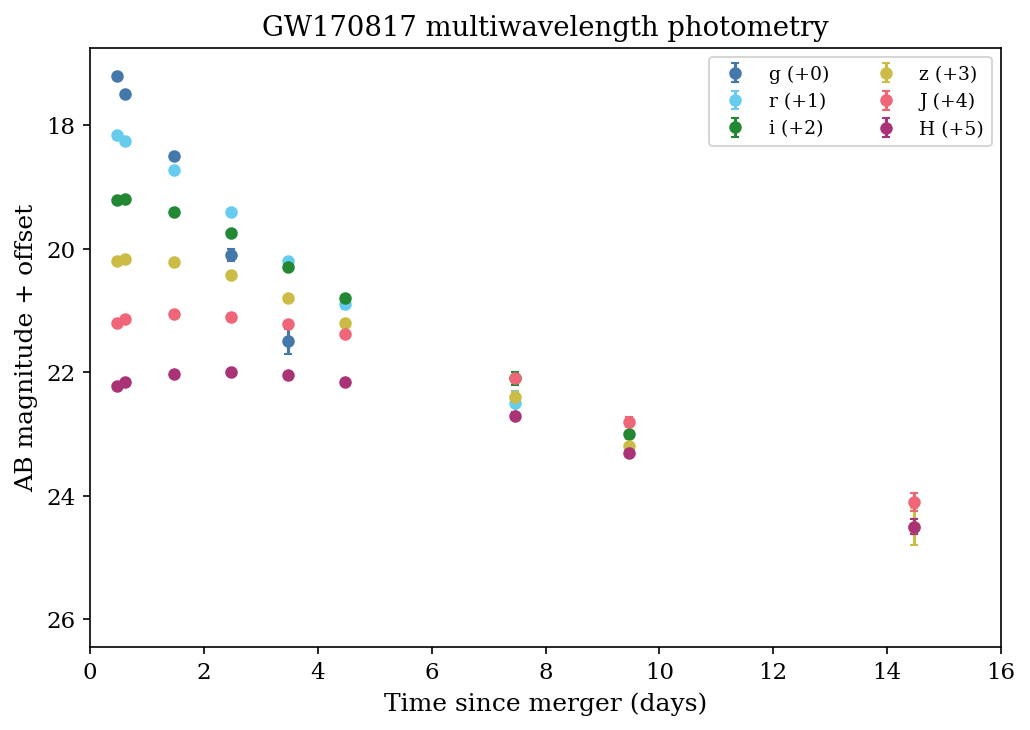

In [2]:
# Cell 2 — Figure 1: GW170817 data overview
df   = load_gw170817_photometry()
ul   = load_upper_limits()

BANDS  = ["g", "r", "i", "z", "J", "H"]
COLORS = {"g": "#4477AA", "r": "#66CCEE", "i": "#228833",
          "z": "#CCBB44", "J": "#EE6677", "H": "#AA3377"}
OFFSET = {"g": 0, "r": 1, "i": 2, "z": 3, "J": 4, "H": 5}  # vertical offsets

fig, ax = plt.subplots(figsize=(7, 5))

for band in BANDS:
    bd = df[df["band"] == band]
    off = OFFSET[band]
    ax.errorbar(
        bd["t_days"], bd["mag"] + off, yerr=bd["mag_err"],
        fmt="o", color=COLORS[band], label=f"{band} (+{off})",
        capsize=2, ms=5
    )
    # Upper limits
    ul_b = ul[ul["band"] == band]
    if len(ul_b):
        ax.scatter(ul_b["t_days"], ul_b["mag_limit"] + off,
                   marker="v", color=COLORS[band], s=40, zorder=5)

ax.invert_yaxis()
ax.set_xlabel("Time since merger (days)")
ax.set_ylabel("AB magnitude + offset")
ax.set_title("GW170817 multiwavelength photometry")
ax.legend(ncol=2, fontsize=9)
ax.set_xlim(0, 16)
plt.tight_layout()
plt.savefig(OUTDIR / "fig1_data_overview.pdf")
plt.show()

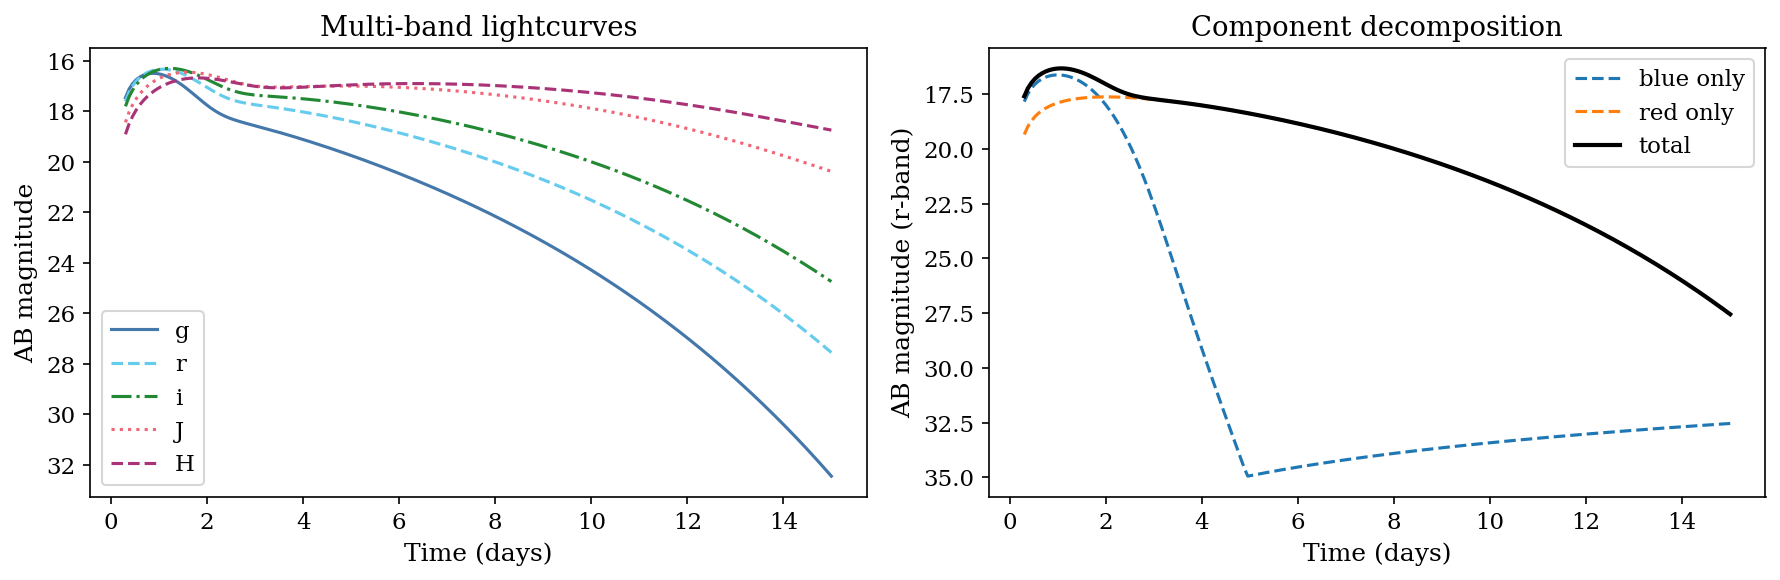

In [3]:
# Cell 3 — Figure 2: Model component contributions
t = np.linspace(0.3, 15, 200)
D = 40.0

blue   = KilonovaComponent(mej=0.025, vej=0.27, kappa=0.5,  name="blue")
red    = KilonovaComponent(mej=0.040, vej=0.15, kappa=10.0, name="red")
model  = MultiComponentKilonova([blue, red])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: optical vs NIR
for band, ls in zip(["g", "r", "i", "J", "H"], ["-","--","-.",":","--"]):
    mag = model.magnitude(t, band=band, distance_mpc=D)
    axes[0].plot(t, mag, ls=ls, label=band, color=COLORS[band])

axes[0].invert_yaxis()
axes[0].set_xlabel("Time (days)")
axes[0].set_ylabel("AB magnitude")
axes[0].set_title("Multi-band lightcurves")
axes[0].legend()

# Right: component decomposition in r-band
comp_mags = model.component_magnitudes(t, band="r", distance_mpc=D)
for name, mag in comp_mags.items():
    axes[1].plot(t, mag, ls="--", label=f"{name} only")
axes[1].plot(t, model.magnitude(t, band="r", distance_mpc=D),
             "k-", lw=2, label="total")
axes[1].invert_yaxis()
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("AB magnitude (r-band)")
axes[1].set_title("Component decomposition")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTDIR / "fig2_model_components.pdf")
plt.show()

In [4]:
# Cell 4 — Run inference (skip if already done)
LABEL = "kilonova_2comp"
RESULT_FILE = OUTDIR / f"{LABEL}_result.json"

df_fit = load_gw170817_photometry(bands=BANDS, t_max=15.0)

likelihood = KilonovaLikelihood(
    data=df_fit, n_components=2,
    distance_mpc=40.0, sigma_floor=0.05
)
priors = gw170817_priors(n_components=2)

result = run_inference(
    likelihood=likelihood, priors=priors,
    outdir=str(OUTDIR), label=LABEL,
    sampler="dynesty", nlive=500,
    clean=False,   # set True to re-run
)

/home/jean/miniconda3/lib/python3.13/site-packages/bilby/core/likelihood.py:127: FutureWarning: Setting non-trivial parameters for <class 'kai.inference.likelihood.KilonovaLikelihood'>. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(msg, FutureWarning)
07:41 bilby INFO    : Running for label 'kilonova_2comp', output will be saved to '../results/gw170817'
07:41 bilby INFO    : Analysis priors:
07:41 bilby INFO    : blue_mej=LogUniform(minimum=0.0001, maximum=0.5, name='blue_mej', latex_label='$M_{ej,\\rm blue}\\ [M_\\odot]$', unit=None, boundary=None)
07:41 bilby INFO    : blue_vej=Uniform(minimum=0.05, maximum=0.5, name='blue_vej', latex_label='$v_{ej,\\rm blue}\\ [c]$', unit=None, boundary=None)
07:41 bilby INFO    : blue_kappa=LogUniform(minimum=0.1, maximum=2.0, name='blue_kappa', latex_label='$\\kappa_{\\rm blue}\\ [\\rm cm^2/g]$', unit=None, boundary=None)
07:41 bilby INFO    

1it [00:00, ?it/s]

/home/jean/miniconda3/lib/python3.13/site-packages/bilby/core/likelihood.py:64: DeprecationWarning: Using parameters as state for KilonovaLikelihood. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(
/home/jean/miniconda3/lib/python3.13/site-packages/bilby/core/likelihood.py:113: FutureWarning: Parameter attribute queried for <class 'kai.inference.likelihood.KilonovaLikelihood'>. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(msg, FutureWarning)
07:51 bilby INFO    : Written checkpoint file ../results/gw170817/kilonova_2comp_resume.pickle
/home/jean/miniconda3/lib/python3.13/site-packages/dynesty/plotting.py:786: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0., max(y0) * 1.05])
/home/jean/minico

08:19 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
08:19 bilby INFO    : Summary of results:
nsamples: 2243
ln_noise_evidence: -36659677.333
ln_evidence: -279.595 +/-  0.357
ln_bayes_factor: 36659397.738 +/-  0.357



ValueError: quantiles must be of length 2

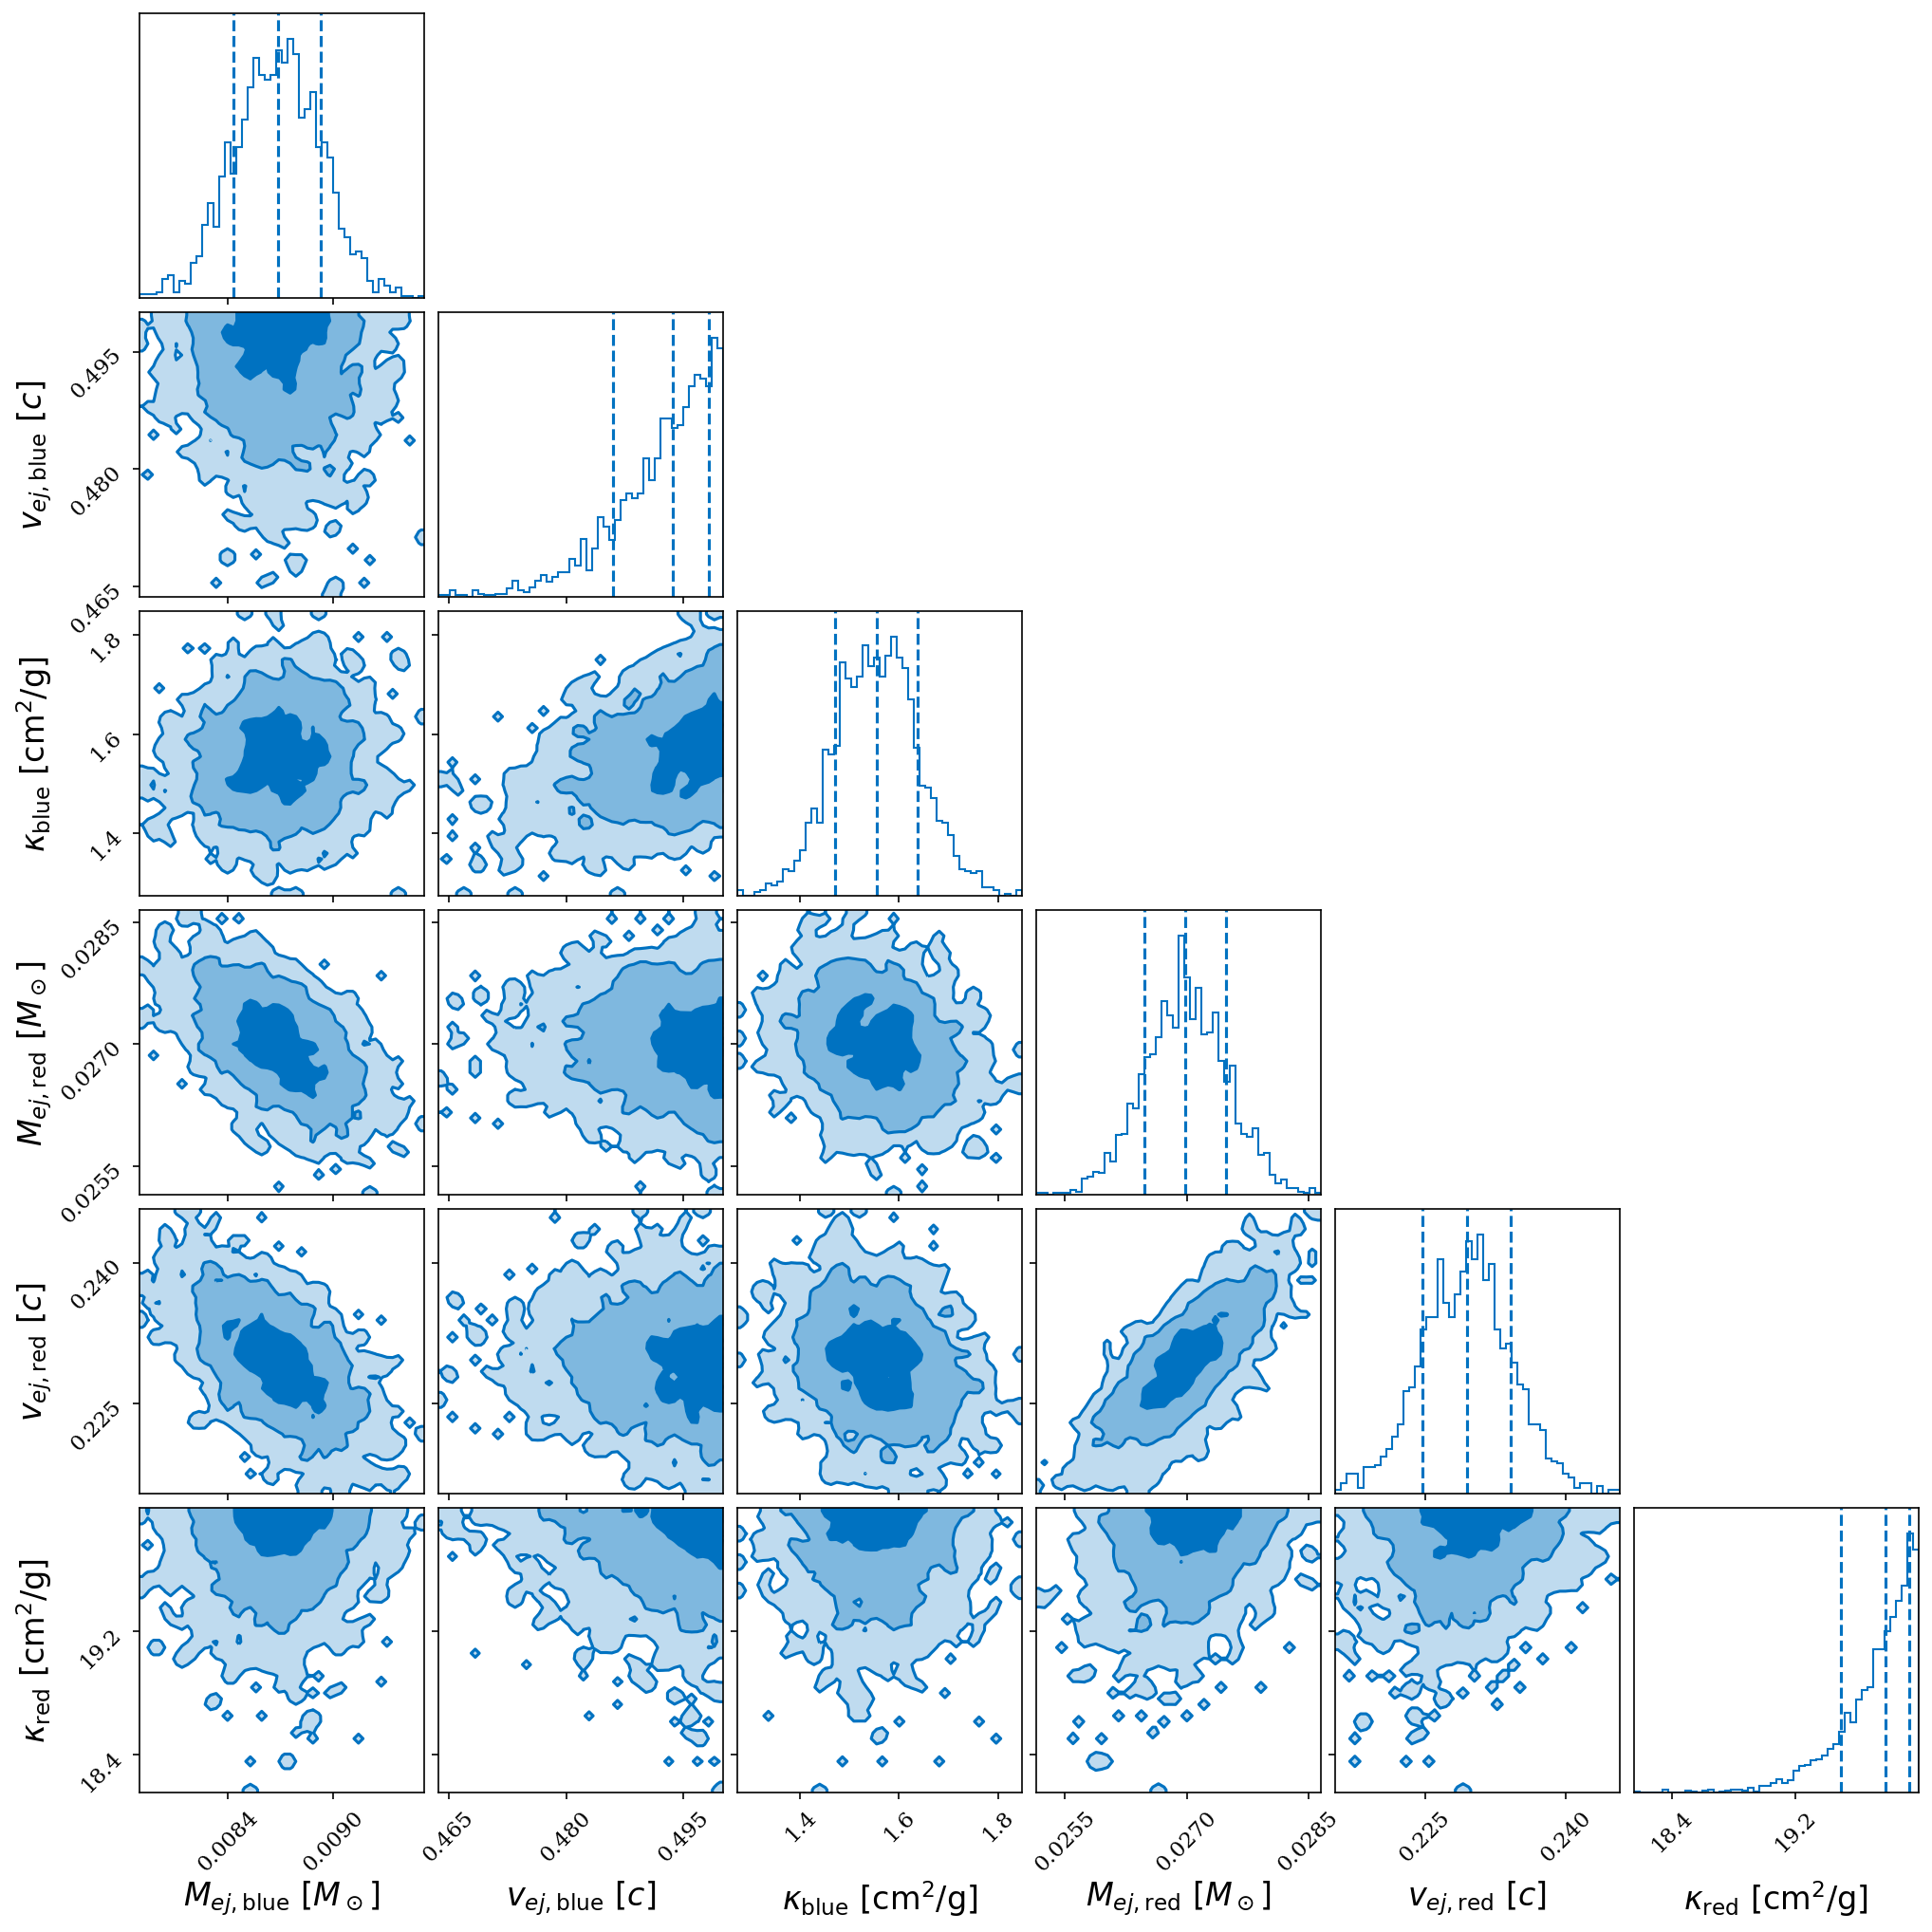

In [5]:
# Cell 5 — Figure 3: Corner plot
fig = result.plot_corner(
    parameters=list(priors.keys()),
    titles=True, quantiles=[0.16, 0.5, 0.84],
    save=False,
)
fig.savefig(OUTDIR / "fig3_corner.pdf", bbox_inches="tight")
plt.show()

# Print credible intervals
print("\nPosterior credible intervals (median ± 1σ):")
for param in priors.keys():
    samples = result.posterior[param]
    lo, med, hi = np.percentile(samples, [16, 50, 84])
    print(f"  {param:20s} = {med:.4f} + {hi-med:.4f} - {med-lo:.4f}")

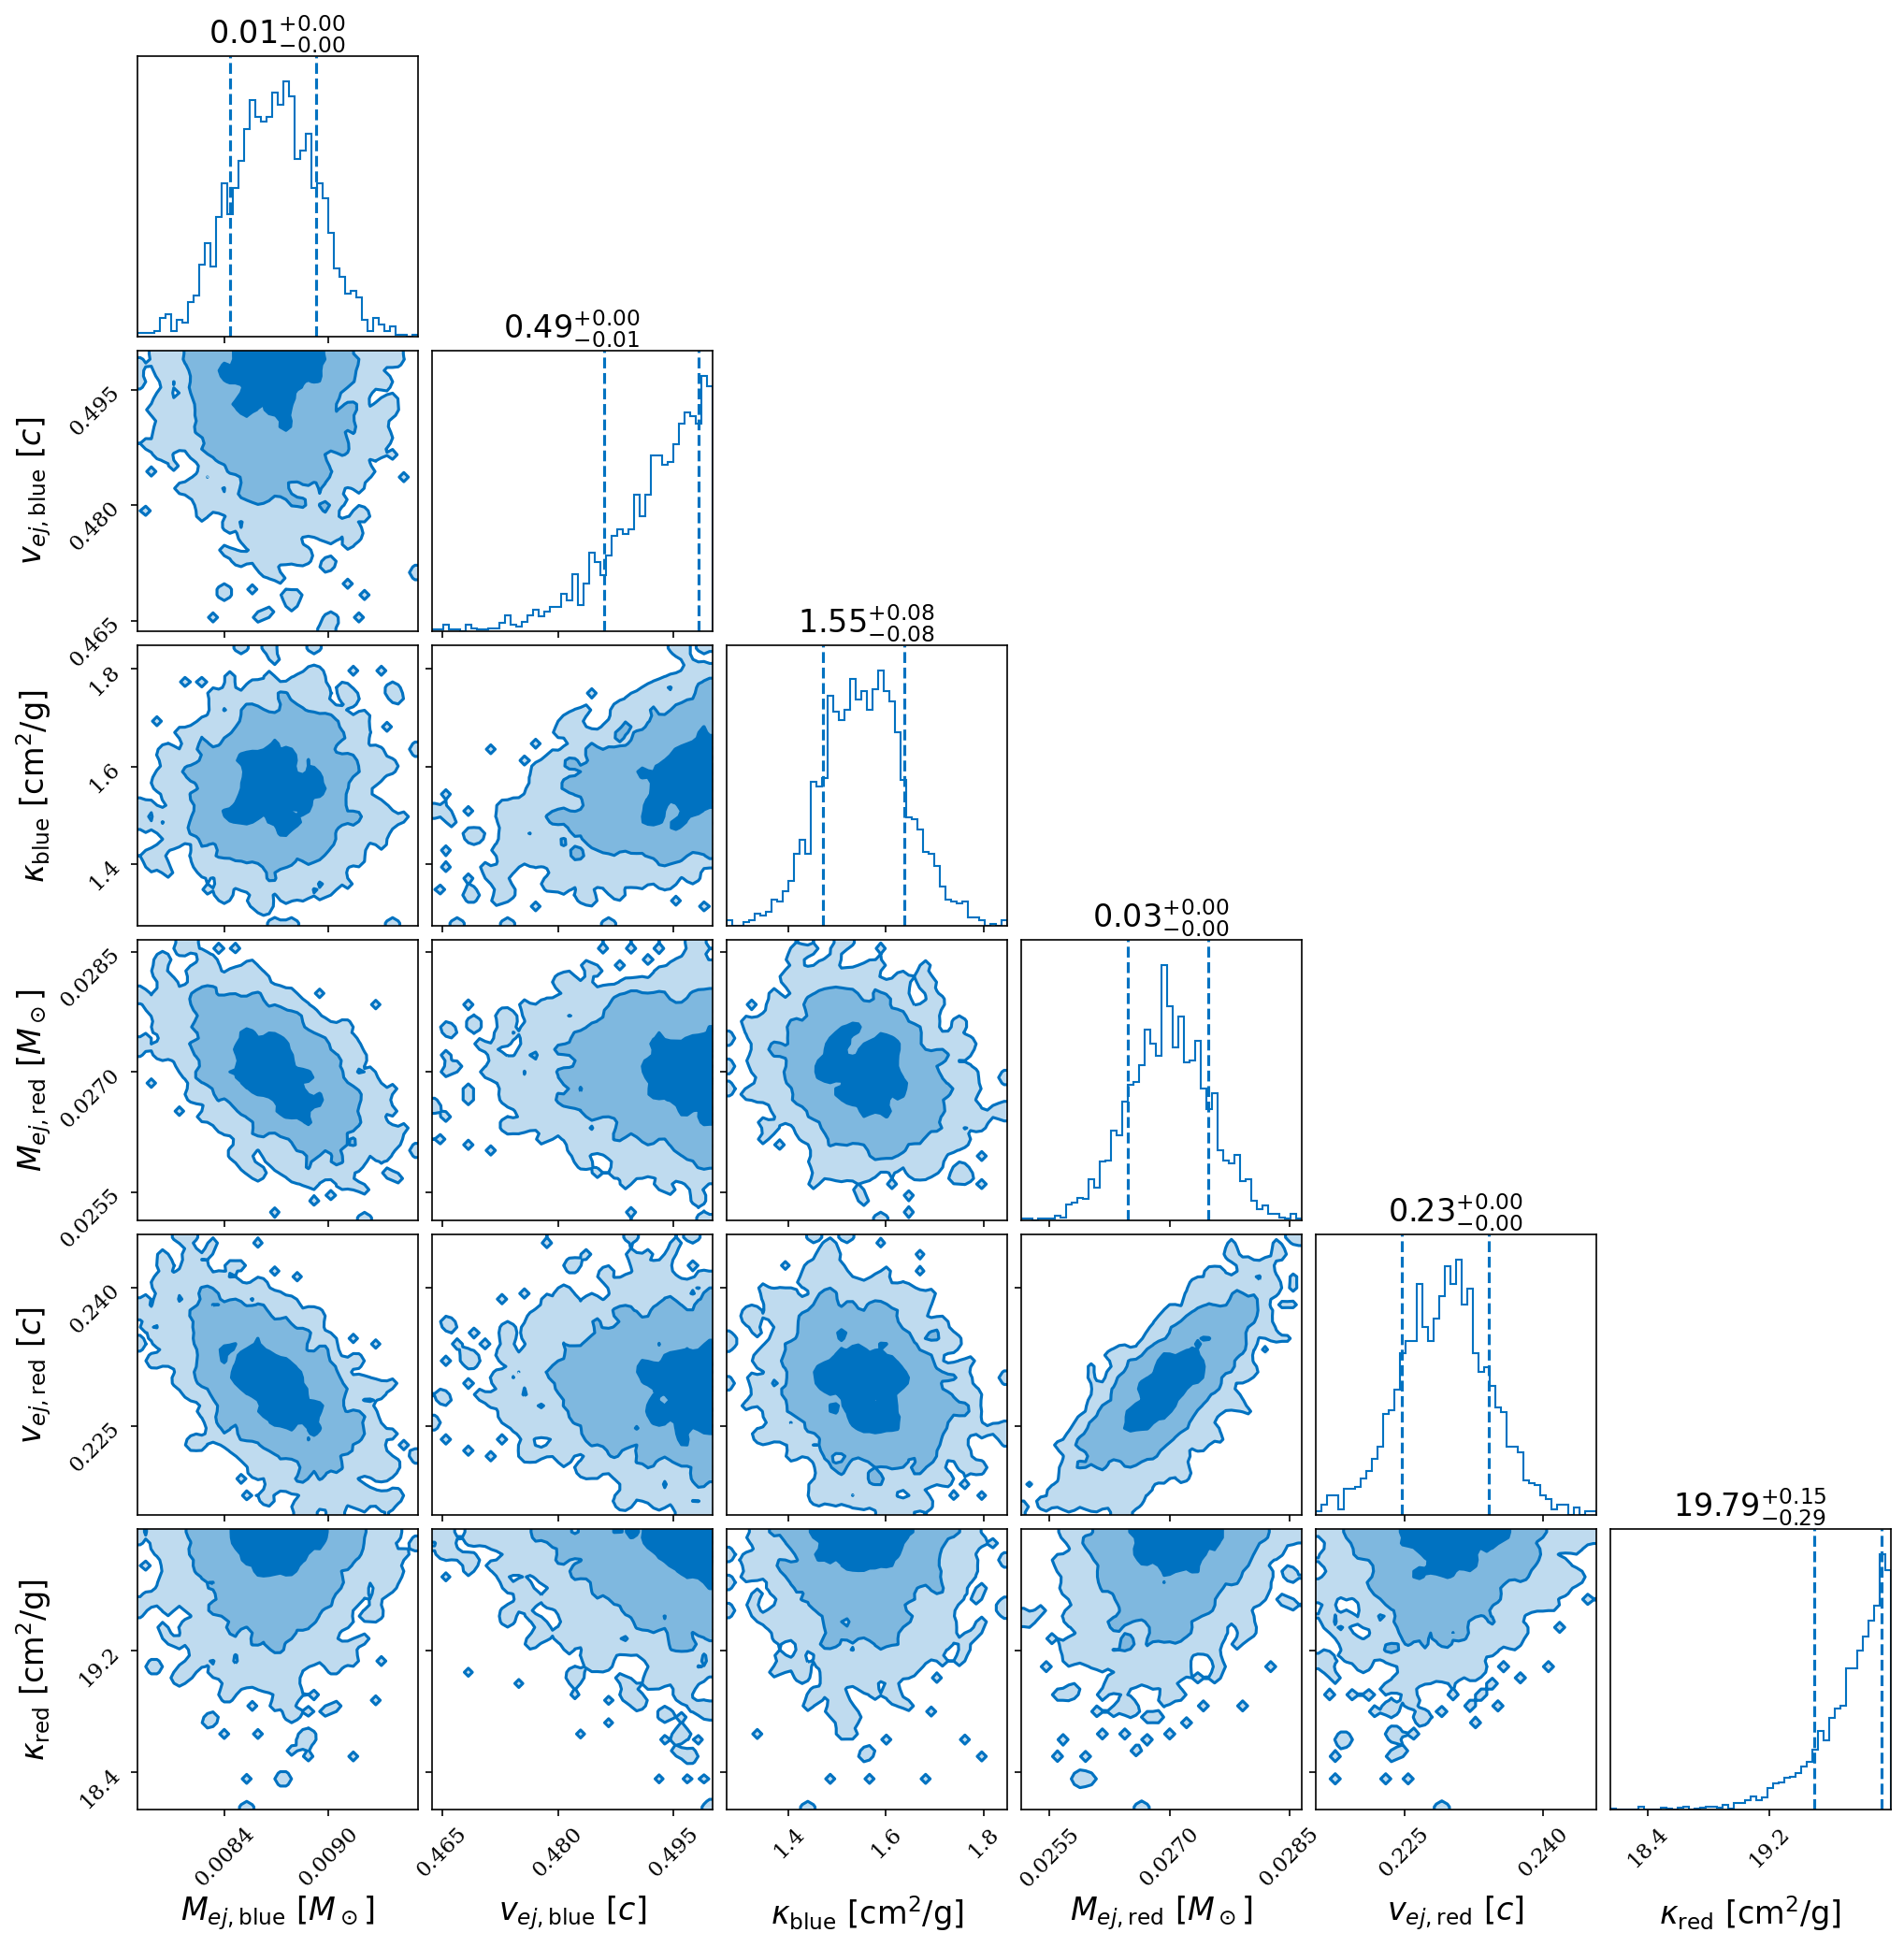


Posterior credible intervals (median ± 1σ):
  blue_mej             = 0.0087 + 0.0002 - 0.0003
  blue_vej             = 0.4936 + 0.0046 - 0.0076
  blue_kappa           = 1.5543 + 0.0825 - 0.0842
  red_mej              = 0.0270 + 0.0005 - 0.0005
  red_vej              = 0.2295 + 0.0046 - 0.0048
  red_kappa            = 19.7878 + 0.1531 - 0.2925

log Evidence (logZ) = -279.59 ± 0.36


In [7]:
# Cell 5 — Figure 3: Corner plot
fig = result.plot_corner(
    parameters=list(priors.keys()),
    titles=True,
    quantiles=[0.16, 0.84],   # bilby v3: 2 values only (lower, upper)
    save=False,
)
fig.savefig(OUTDIR / "fig3_corner.pdf", bbox_inches="tight")
plt.show()

# Print credible intervals separately
print("\nPosterior credible intervals (median ± 1σ):")
for param in priors.keys():
    samples = result.posterior[param]
    lo, med, hi = np.percentile(samples, [16, 50, 84])
    print(f"  {param:20s} = {med:.4f} + {hi-med:.4f} - {med-lo:.4f}")

print(f"\nlog Evidence (logZ) = {result.log_evidence:.2f} ± {result.log_evidence_err:.2f}")

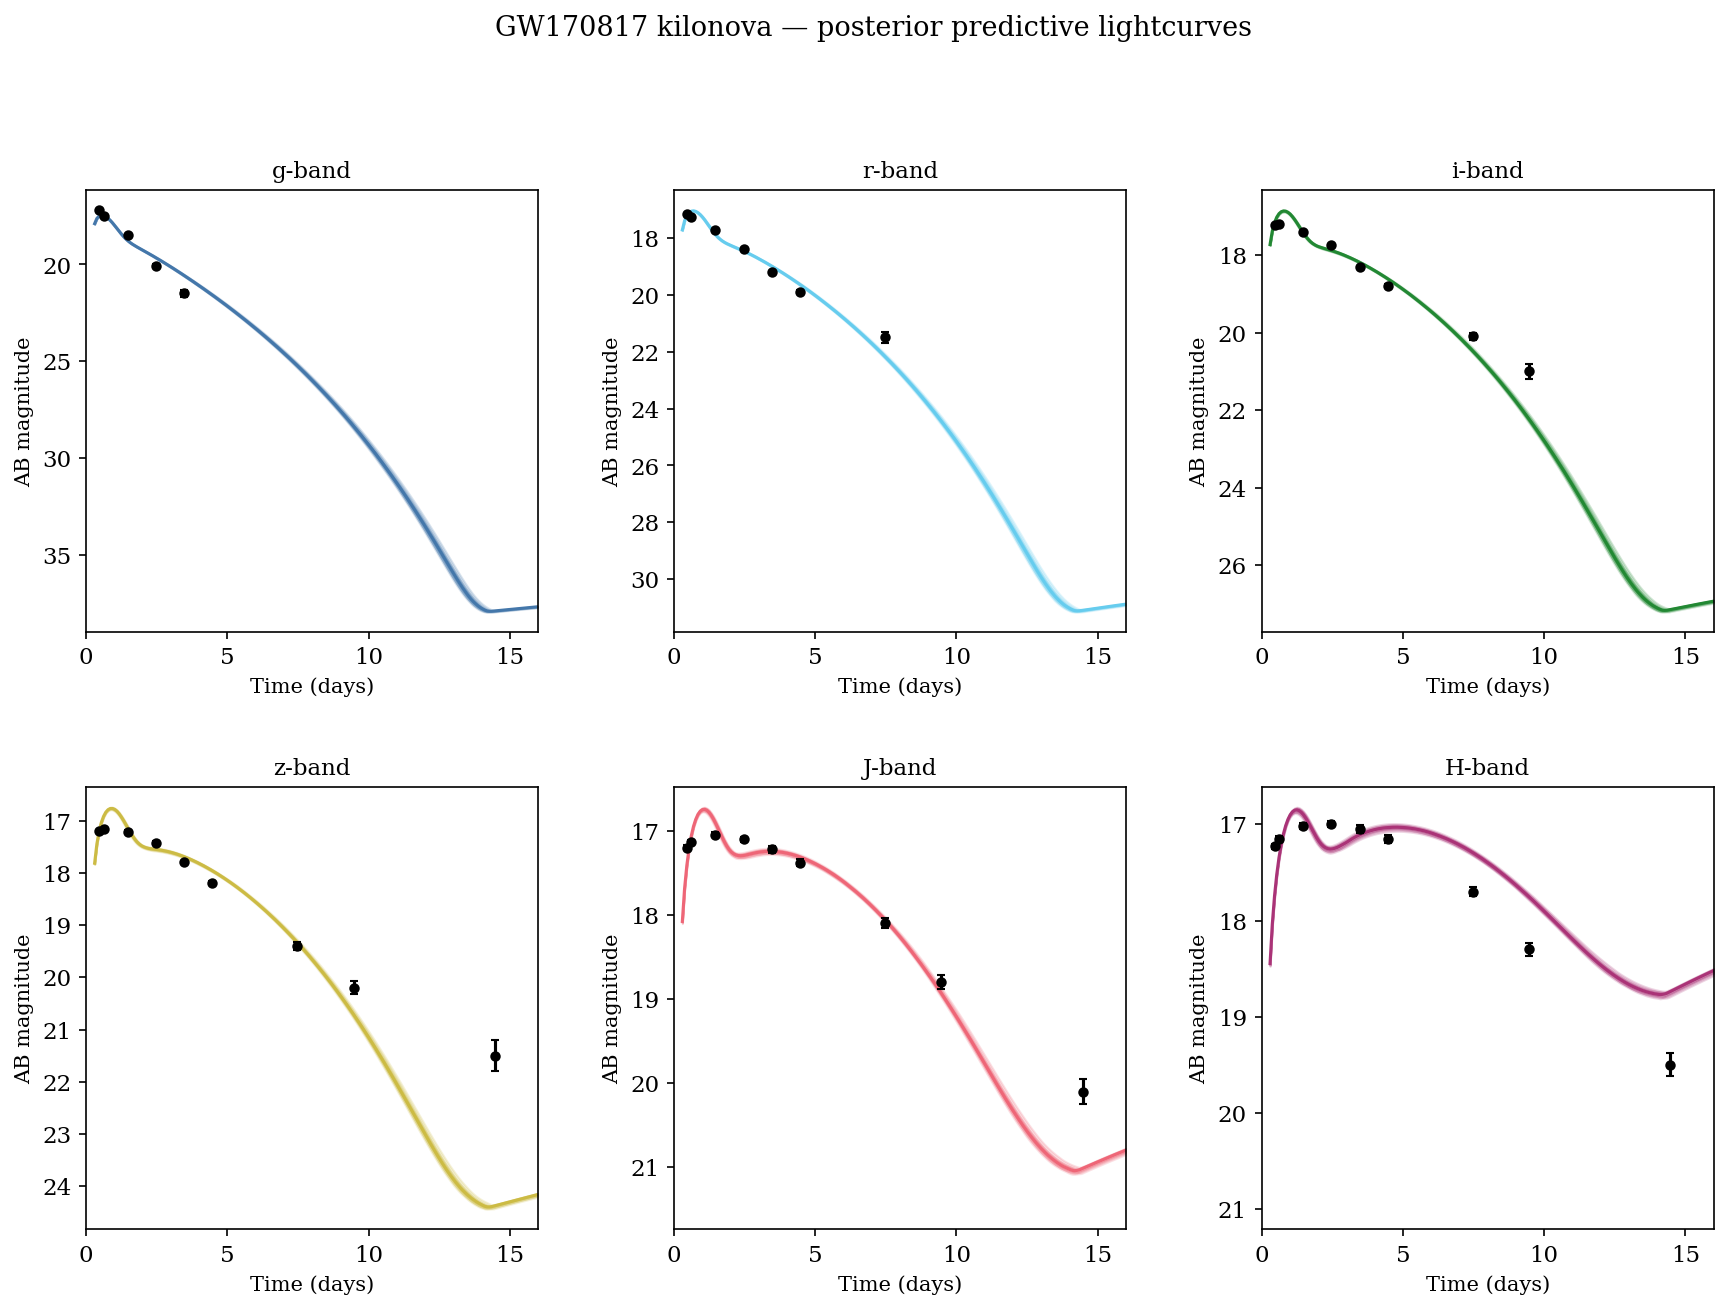

In [6]:
# Cell 6 — Figure 4: Posterior predictive lightcurves (paper main figure)
t_plot = np.linspace(0.3, 16, 200)
n_samples = 200
post_samples = result.posterior.sample(n_samples)

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.3)

for idx, band in enumerate(BANDS):
    ax  = fig.add_subplot(gs[idx // 3, idx % 3])
    col = COLORS[band]

    # Posterior predictive envelope
    mag_samples = []
    for _, row in post_samples.iterrows():
        m = build_model_from_params(row.to_dict(), COMPONENT_NAMES[2])
        mag_samples.append(
            m.magnitude(t_plot, band=band, distance_mpc=40.0)
        )
    mag_samples = np.array(mag_samples)

    # Shaded 1-sigma and 2-sigma bands
    ax.fill_between(
        t_plot,
        np.percentile(mag_samples, 5,  axis=0),
        np.percentile(mag_samples, 95, axis=0),
        alpha=0.2, color=col, label="90% CI"
    )
    ax.fill_between(
        t_plot,
        np.percentile(mag_samples, 16, axis=0),
        np.percentile(mag_samples, 84, axis=0),
        alpha=0.4, color=col, label="68% CI"
    )
    ax.plot(t_plot, np.median(mag_samples, axis=0),
            color=col, lw=1.5, label="median")

    # Data
    bd = df_fit[df_fit["band"] == band]
    ax.errorbar(bd["t_days"], bd["mag"], yerr=bd["mag_err"],
                fmt="ko", ms=4, capsize=2, zorder=5)

    # Upper limits
    ul_b = ul[ul["band"] == band]
    if len(ul_b):
        ax.scatter(ul_b["t_days"], ul_b["mag_limit"],
                   marker="v", color="k", s=30, zorder=5)

    ax.invert_yaxis()
    ax.set_xlabel("Time (days)", fontsize=10)
    ax.set_ylabel("AB magnitude",  fontsize=10)
    ax.set_title(f"{band}-band", fontsize=11)
    ax.set_xlim(0, 16)

fig.suptitle(
    "GW170817 kilonova — posterior predictive lightcurves",
    fontsize=13, y=1.01
)
plt.savefig(OUTDIR / "fig4_posterior_predictive.pdf", bbox_inches="tight")
plt.show()